In [ ]:
!pip install tensorflow matplotlib scikit-learn pandas numpy


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

# Path to your ZIP file in Google Drive
zip_path = '/content/drive/MyDrive/archive.zip'

# Folder where you want to extract the files
extract_path = '/content/malaria_full'

# Create the extraction folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipping complete! Files are in:", extract_path)

Unzipping complete! Files are in: /content/malaria_full


In [ ]:
import shutil
import random
import os

# Original folders

# New folder for our smaller dataset
target_dir = '/content/malaria_small'
os.makedirs(target_dir, exist_ok=True)

# Inspect the contents of the extraction path to find the correct subfolder
extract_path = '/content/malaria_full'
print(f"Contents of {extract_path}: {os.listdir(extract_path)}")

# Assuming the actual images are within a 'cell_images' subfolder based on common dataset structures.
# Adjust this if os.listdir(extract_path) shows a different top-level folder.
base_data_path = os.path.join(extract_path, 'cell_images')
source_para = os.path.join(base_data_path, 'Parasitized')
source_uninf = os.path.join(base_data_path, 'Uninfected')
# --- End of fix ---

# For each class, pick 5000 random images and copy them
for class_name, source_folder in [('Parasitized', source_para), ('Uninfected', source_uninf)]:
    all_images = os.listdir(source_folder)
    selected = random.sample(all_images, 5000)   # pick 5000

    # Create a subfolder inside target_dir for this class
    class_target = os.path.join(target_dir, class_name)
    os.makedirs(class_target, exist_ok=True)

    # Copy each selected image
    for img in selected:
        src = os.path.join(source_folder, img)
        dst = os.path.join(class_target, img)
        shutil.copy(src, dst)

    print(f"Copied {len(selected)} images to {class_target}")

Contents of /content/malaria_full: ['cell_images']
Copied 5000 images to /content/malaria_small/Parasitized
Copied 5000 images to /content/malaria_small/Uninfected


In [ ]:
import shutil
import random
import os

small_dir = '/content/malaria_small'
test_dir = '/content/malaria_test'

# Create test folder with same structure
os.makedirs(test_dir, exist_ok=True)

for class_name in ['Parasitized', 'Uninfected']:
    class_path = os.path.join(small_dir, class_name)
    images = os.listdir(class_path)
    # Pick 10% (500 images) for test
    test_images = random.sample(images, 500)

    # Move them to test folder
    test_class_dir = os.path.join(test_dir, class_name)
    os.makedirs(test_class_dir, exist_ok=True)
    for img in test_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(test_class_dir, img)
        shutil.move(src, dst)   # move, not copy

    print(f"Moved {len(test_images)} images from {class_name} to test set.")

Moved 500 images from Parasitized to test set.
Moved 500 images from Uninfected to test set.


In [ ]:
for root, dirs, files in os.walk('/content/malaria_small'):
    print(root, len(files))

/content/malaria_small 0
/content/malaria_small/Parasitized 4500
/content/malaria_small/Uninfected 4500


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image size and batch size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,                # Normalize pixel values to [0,1]
    rotation_range=20,              # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,          # Randomly shift images horizontally
    height_shift_range=0.2,         # Randomly shift images vertically
    shear_range=0.2,                # Shear transformations
    zoom_range=0.2,                 # Random zoom
    horizontal_flip=True,           # Flip images horizontally
    validation_split=0.1111         # Use 11.11% of malaria_small for validation
)                                  # This gives 1000 validation images (out of 9000)

# Validation and test generators
val_test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1111         # same split for validation (used only for validation generator)
)

In [ ]:
# Paths to your folders
train_val_dir = '/content/malaria_small'      # has Parasitized and Uninfected subfolders
test_dir = '/content/malaria_test'            # also has same subfolders

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',            # binary labels (0 = Uninfected, 1 = Parasitized)
    subset='training',              # use the training portion
    shuffle=True                    # shuffle for training
)

# Validation generator
validation_generator = val_test_datagen.flow_from_directory(
    train_val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',            # use the validation portion
    shuffle=False                   # no need to shuffle for validation
)

# Test generator
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False                   # keep order for evaluation
)

Found 8000 images belonging to 2 classes.
Found 998 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


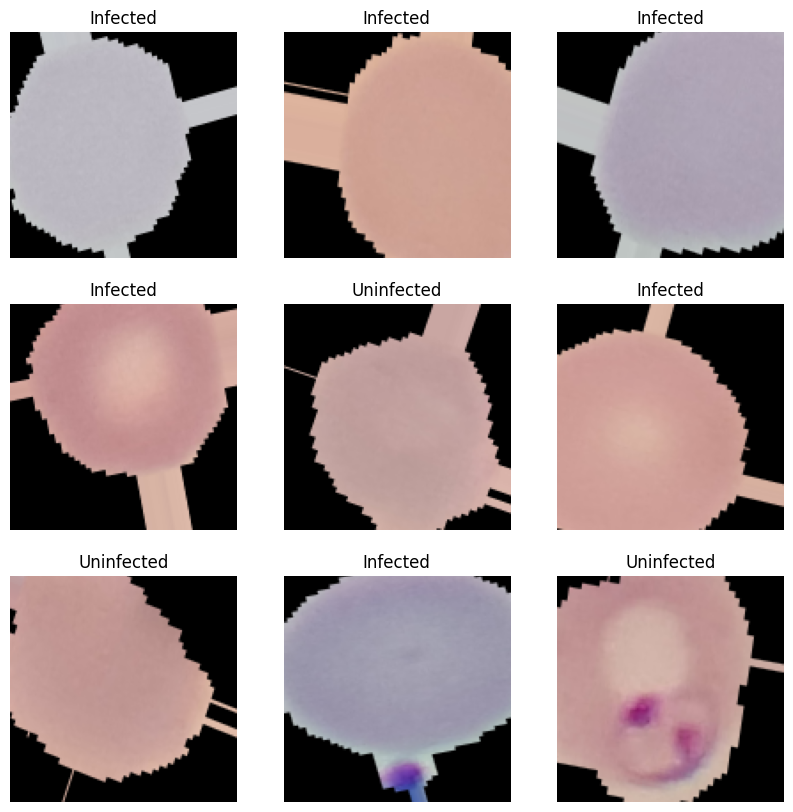

In [ ]:
import matplotlib.pyplot as plt

# Get a batch of training images
x_batch, y_batch = next(train_generator)

# Plot the first 9 images
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.title('Infected' if y_batch[i]==1 else 'Uninfected')
    plt.axis('off')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load MobileNetV2 without the top classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model layers (they won't be trained)
base_model.trainable = False

# Add custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)          # reduces each feature map to a single number
x = Dense(128, activation='relu')(x)     # fully connected layer
x = Dropout(0.5)(x)                       # helps prevent overfitting
predictions = Dense(1, activation='sigmoid')(x)   # output layer for binary classification

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# View the model architecture
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
!pip install opencv-python

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Optionally save the best model
checkpoint = ModelCheckpoint('best_malaria_model.keras', monitor='val_loss', save_best_only=True)

callbacks = [early_stop, reduce_lr, checkpoint]

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 146s 584ms/step - accuracy: 0.8851 - loss: 0.2898 - precision: 0.8693 - recall: 0.9065 - val_accuracy: 0.8488 - val_loss: 0.3517 - val_precision: 0.7762 - val_recall: 0.9777 - learning_rate: 2.0000e-04
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 144s 574ms/step - accuracy: 0.8931 - loss: 0.2794 - precision: 0.8770 - recall: 0.9145 - val_accuracy: 0.8579 - val_loss: 0.3544 - val_precision: 0.7866 - val_recall: 0.9797 - learning_rate: 2.0000e-04
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 202s 808ms/step - accuracy: 0.8942 - loss: 0.2736 - precision: 0.8776 - recall: 0.9162 - val_accuracy: 0.8488 - val_loss: 0.3555 - val_precision: 0.7744 - val_recall: 0.9817 - learning_rate: 2.0000e-04
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 142s 568ms/step - accuracy: 0.8934 - loss: 0.2735 - precision: 0.8796 - recall: 0.9115 - val_accuracy: 0.8488 - val_loss: 0.3719 - val_precision: 0.7744 - val_recall: 0.9817 - learning_rate: 2.0000e-04
Epoch 5/20
250/250 ━━━━━━━━━━━━━

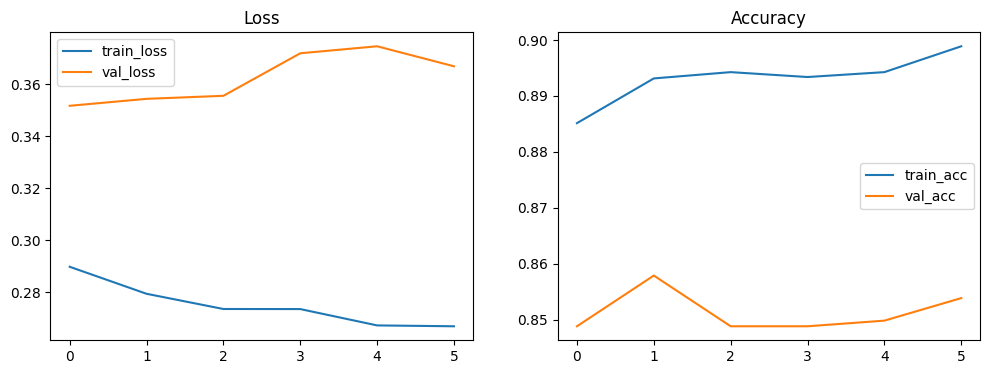

In [ ]:
def plot_training(history):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(history.history['loss'], label='train_loss')
    axes[0].plot(history.history['val_loss'], label='val_loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[1].plot(history.history['accuracy'], label='train_acc')
    axes[1].plot(history.history['val_accuracy'], label='val_acc')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    plt.show()

plot_training(history)

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 403ms/step - accuracy: 0.8810 - loss: 0.2745 - precision: 0.8279 - recall: 0.9620
Test Accuracy: 0.8810
Test Precision: 0.8279
Test Recall: 0.9620
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 397ms/step
              precision    recall  f1-score   support

 Parasitized       0.95      0.80      0.87       500
  Uninfected       0.83      0.96      0.89       500

    accuracy                           0.88      1000
   macro avg       0.89      0.88      0.88      1000
weighted avg       0.89      0.88      0.88      1000

Confusion Matrix:
[[400 100]
 [ 19 481]]


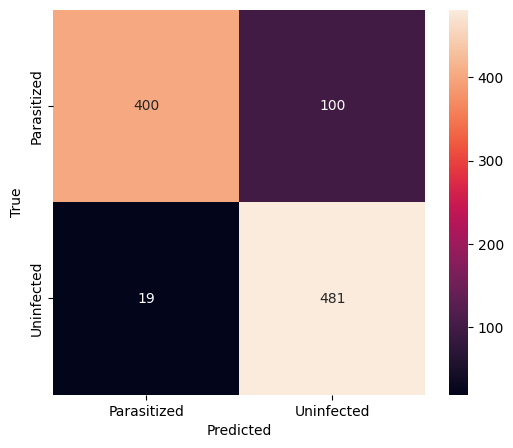

In [ ]:
# Evaluate on test set
test_loss, test_acc, test_precision, test_recall = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

# Generate predictions for confusion matrix and classification report
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict all test images
test_generator.reset()  # ensure we start from the beginning
predictions = model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# True labels
true_classes = test_generator.classes

# Get class labels
class_labels = list(test_generator.class_indices.keys())  # ['Uninfected', 'Parasitized']

# Print classification report
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix as a heatmap (optional)
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 397ms/step
Test ROC-AUC: 0.9675


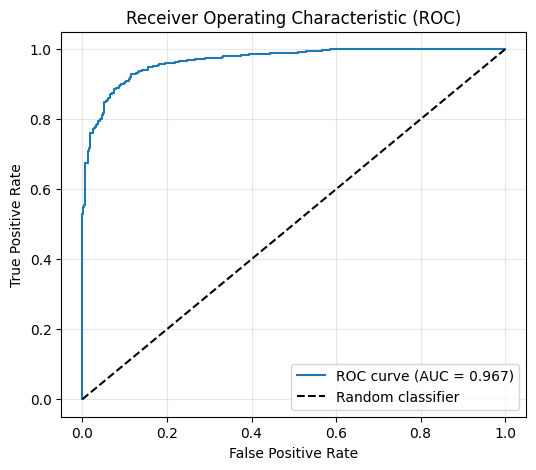

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# Predict probabilities for the test set
test_generator.reset()
y_pred_prob = model.predict(test_generator, verbose=1).flatten()
y_true = test_generator.classes

# Compute ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)
print(f"Test ROC-AUC: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Displaying Grad-CAM for Parasitized sample: /content/malaria_test/Parasitized/C51AP12thinF_IMG_20150724_153313_cell_105.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


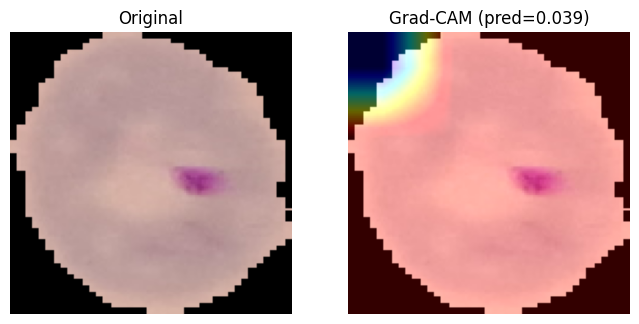

Displaying Grad-CAM for Uninfected sample: /content/malaria_test/Uninfected/C112P73ThinF_IMG_20150930_131753_cell_22.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


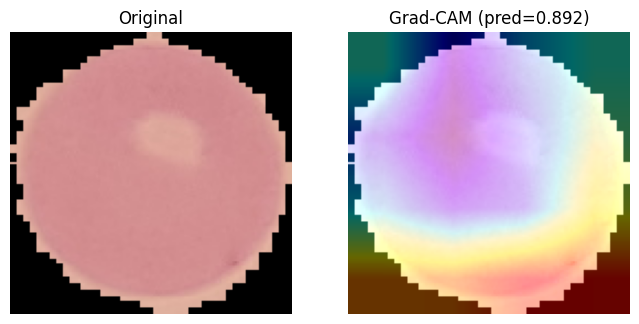

In [ ]:
import cv2
import os
import random

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    #Generate Grad-CAM heatmap for a given image
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap

def display_gradcam(img_path, model, last_conv_layer_name='Conv_1', alpha=0.4):
    #Load image, compute Grad-CAM, and overlay heatmap."""
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128, 128))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    pred = model.predict(img_array)[0][0]
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Rescale heatmap to original image size
    heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + np.array(img)
    superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1); plt.imshow(img); plt.title('Original'); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(superimposed_img);
    plt.title(f'Grad-CAM (pred={pred:.3f})'); plt.axis('off')
    plt.show()

# Example pick a few images from the test set and visualise
test_parasitized = '/content/malaria_test/Parasitized'
test_uninfected = '/content/malaria_test/Uninfected'

# Function to safely get a sample image path
def get_sample_image_path(directory_path, class_name):
    if not os.path.exists(directory_path):
        print(f"Error: Directory '{directory_path}' for {class_name} not found. Please ensure the test set creation cell (CwQ8n_-XIqee) ran successfully.")
        return None
    if not os.path.isdir(directory_path):
        print(f"Error: Path '{directory_path}' for {class_name} is not a directory.")
        return None

    images = os.listdir(directory_path)
    if not images:
        print(f"Warning: Directory '{directory_path}' for {class_name} exists but is empty. Cannot sample an image.")
        return None
    return os.path.join(directory_path, random.choice(images))

sample_para = get_sample_image_path(test_parasitized, 'Parasitized')
sample_uninf = get_sample_image_path(test_uninfected, 'Uninfected')

if sample_para:
    print(f"Displaying Grad-CAM for Parasitized sample: {sample_para}")
    display_gradcam(sample_para, model)
else:
    print("Skipping Grad-CAM for parasitized image.")

if sample_uninf:
    print(f"Displaying Grad-CAM for Uninfected sample: {sample_uninf}")
    display_gradcam(sample_uninf, model)
else:
    print("Skipping Grad-CAM for uninfected image.")
